In [2]:
!pip install qiskit qiskit-ibm-runtime qiskit-aer pylatexenc

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached cffi-2.0.0-cp311-cp311-win_amd64.whl.metadata (2.6 kB)
   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   ------------ --------------------------- 2.9/9.1 MB 16.8 MB/s eta 0:00:01
   ---------------------------- ----------- 6.6/9.1 MB 17.5 MB/s eta 0:00:01
   ---------------------------- ----------- 6.6/9.1 MB 17.5 MB/s eta 0:00:01
   ------------------------------------ --- 8.4/9.1 MB 12.1 MB/s eta 0:00:01
   ---------------------------------------- 9.1/9.1 MB 9.0 MB/s  0:00:01
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 26.7 MB/s  0:00:00
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ----- ---------------------------------- 1.3/9.6 MB 6.7 MB/s eta 0:00:02
   ---------- ----------------------------- 2.6/9.6 MB 6.0 MB/s eta 0:00:02
   ---------- 

  DEPRECATION: Building 'pylatexenc' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'pylatexenc'. Discussion can be found at https://github.com/pypa/pip/issues/6334
ERROR: Could not install packages due to an OSError: [Errno 28] No space left on device


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: C:\Users\DELL\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [1]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector, plot_histogram
from qiskit_aer import AerSimulator
from IPython.display import display


Circuit for Experiment 1:


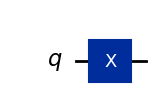


State Vector:


<IPython.core.display.Latex object>


Bloch Sphere:


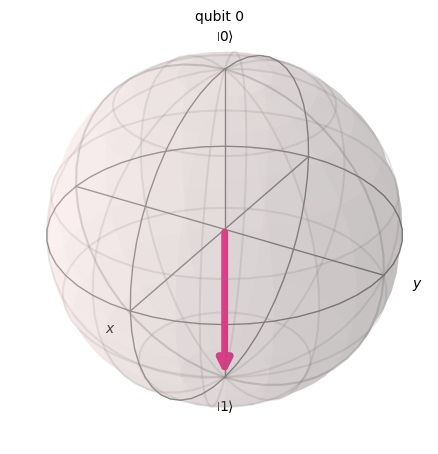

In [2]:
# 1. 
qc1 = QuantumCircuit(1)
qc1.x(0)
print("Circuit for Experiment 1:")
display(qc1.draw('mpl'))
state1 = Statevector(qc1)
print("\nState Vector:")
display(state1.draw('latex'))
print("\nBloch Sphere:")
display(plot_bloch_multivector(state1))


--- Applying Y Gate ---


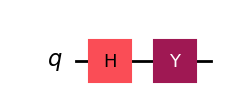

<IPython.core.display.Latex object>

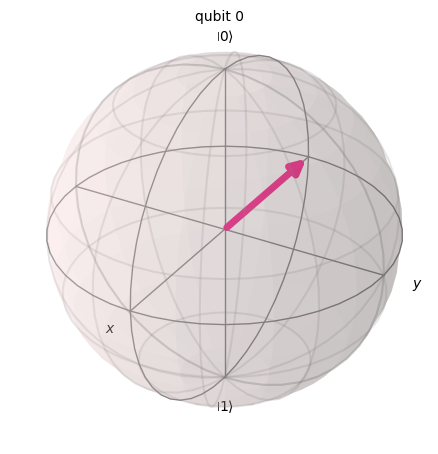


--- Applying Z Gate ---


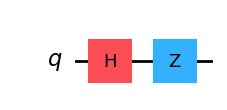

<IPython.core.display.Latex object>

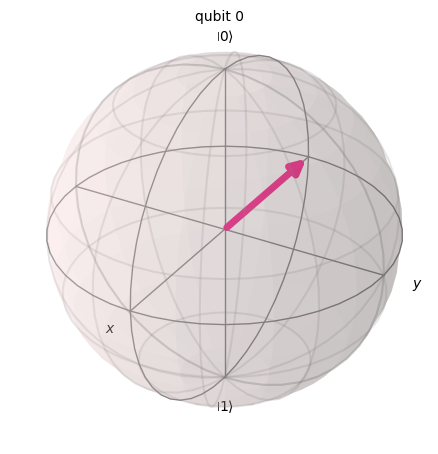


--- Applying Phase (pi/2) Gate ---


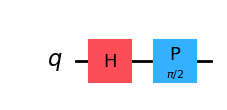

<IPython.core.display.Latex object>

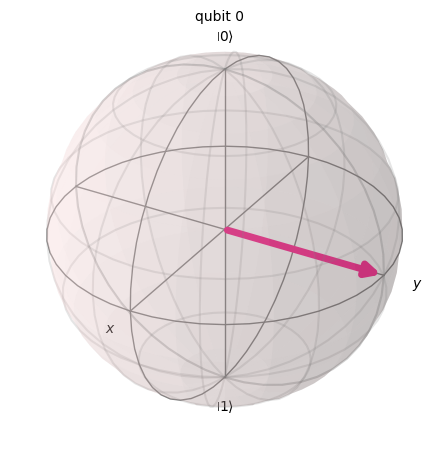


--- Applying S Gate ---


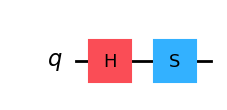

<IPython.core.display.Latex object>

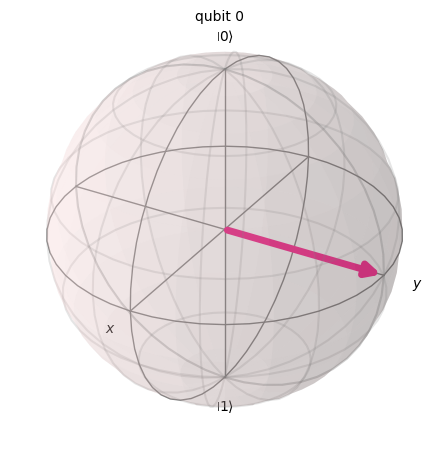


--- Applying S† (Sdg) Gate ---


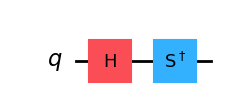

<IPython.core.display.Latex object>

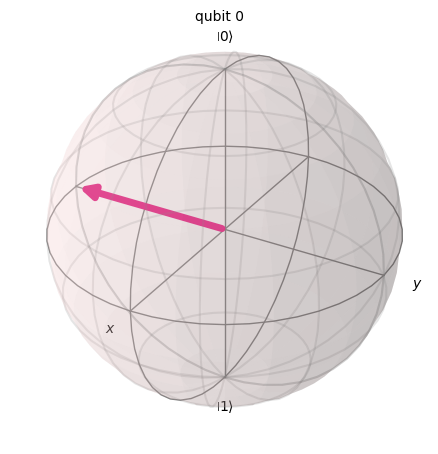


--- Applying T Gate ---


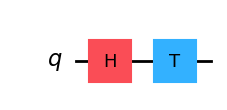

<IPython.core.display.Latex object>

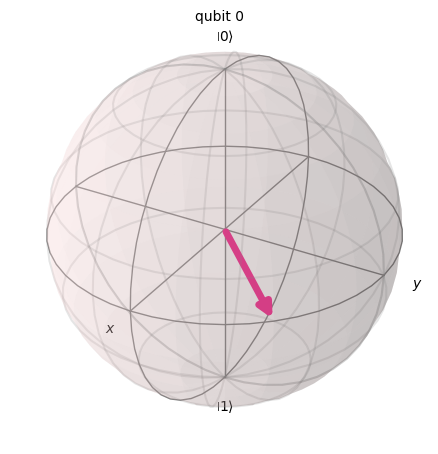


--- Applying T† (Tdg) Gate ---


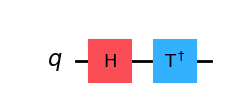

<IPython.core.display.Latex object>

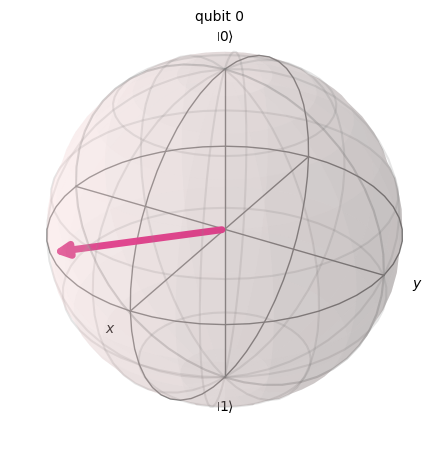

In [7]:
gates = {
    'Y': lambda qc: qc.y(0),
    'Z': lambda qc: qc.z(0),
    'Phase (pi/2)': lambda qc: qc.p(np.pi/2, 0),
    'S': lambda qc: qc.s(0),
    'S† (Sdg)': lambda qc: qc.sdg(0),
    'T': lambda qc: qc.t(0),
    'T† (Tdg)': lambda qc: qc.tdg(0)
}

for gate_name, apply_gate in gates.items():
    print(f"\n--- Applying {gate_name} Gate ---")
    qc2 = QuantumCircuit(1)
    qc2.h(0)
    
    apply_gate(qc2)

    # Draw circuit
    display(qc2.draw('mpl'))
    state2 = Statevector(qc2)
    display(state2.draw('latex'))
    display(plot_bloch_multivector(state2))


--- Circuit (a) ---


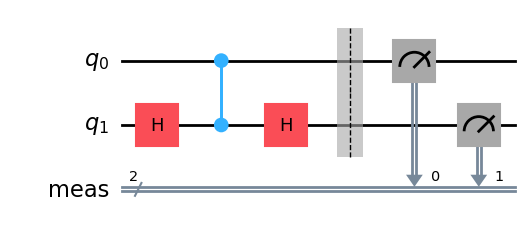

Measurement Results: {'00': 1024}


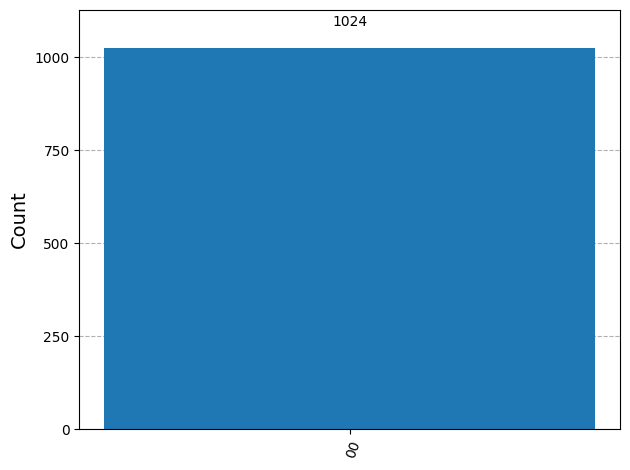


--- Circuit (b) ---


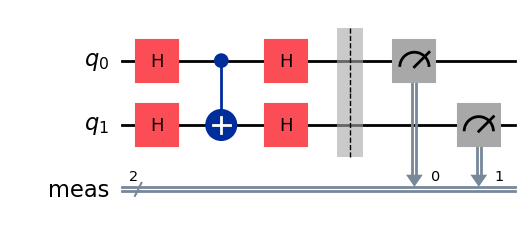

Measurement Results: {'00': 1024}


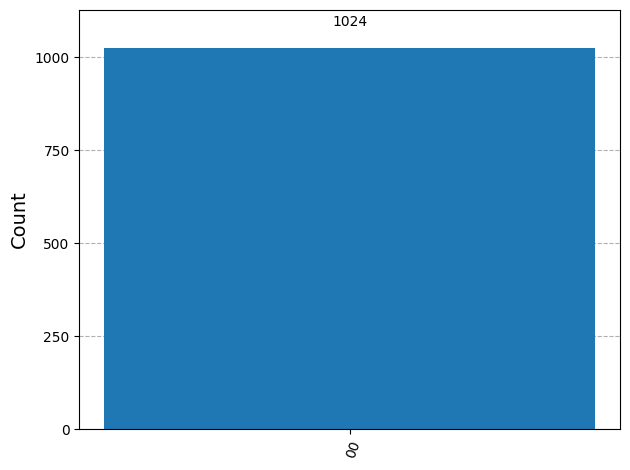


--- Circuit (c) ---


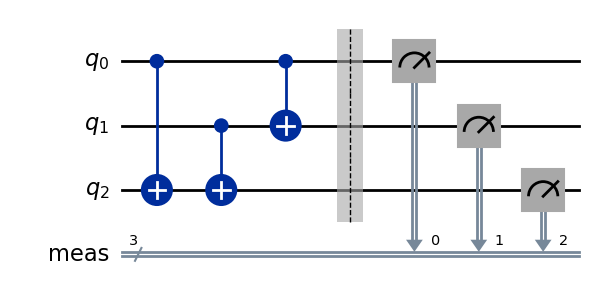

Measurement Results: {'000': 1024}


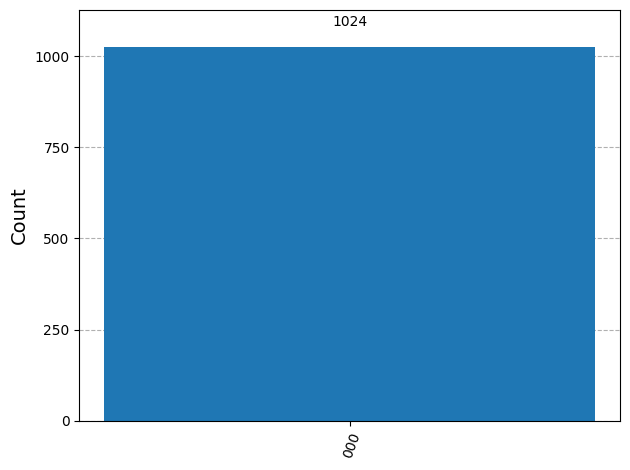


--- Circuit (d) ---


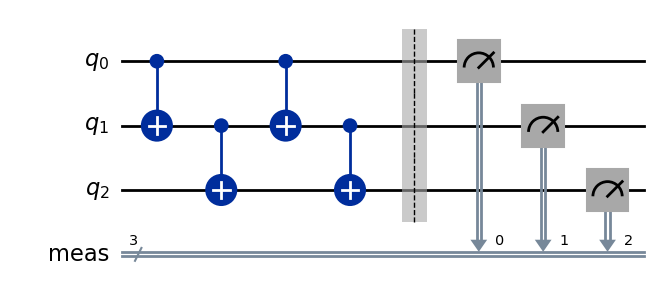

Measurement Results: {'000': 1024}


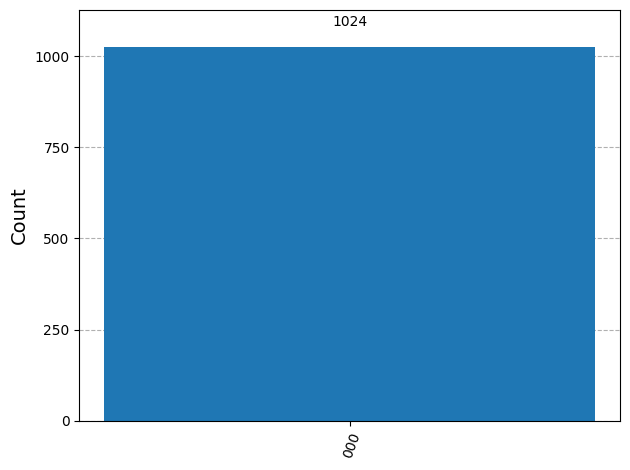

In [10]:
from qiskit.primitives import StatevectorSampler
circuits = []

# (a) 2 Qubits: Control on q0, H-Z-H on q1
qc_a = QuantumCircuit(2)
qc_a.h(1)
qc_a.cz(0, 1)
qc_a.h(1)
qc_a.measure_all()
circuits.append(("Circuit (a)", qc_a))

# (b) 2 Qubits: H on both, CNOT(0->1), H on both
qc_b = QuantumCircuit(2)
qc_b.h(0)
qc_b.h(1)
qc_b.cx(0, 1) 
qc_b.h(0)
qc_b.h(1)
qc_b.measure_all()
circuits.append(("Circuit (b)", qc_b))

# (c) 3 Qubits: CNOT(0->2), CNOT(1->2), CNOT(0->1)
qc_c = QuantumCircuit(3)
qc_c.cx(0, 2)
qc_c.cx(1, 2)
qc_c.cx(0, 1)
qc_c.measure_all()
circuits.append(("Circuit (c)", qc_c))

# (d) 3 Qubits: CNOT(0->1), CNOT(1->2), CNOT(0->1), CNOT(1->2)
qc_d = QuantumCircuit(3)
qc_d.cx(0, 1)
qc_d.cx(1, 2)
qc_d.cx(0, 1)
qc_d.cx(1, 2)
qc_d.measure_all()
circuits.append(("Circuit (d)", qc_d))
sampler = StatevectorSampler()

for name, qc in circuits:
    print(f"\n--- {name} ---")
    display(qc.draw('mpl'))
    job = sampler.run([qc])
    result = job.result()
    pub_result = result[0]
    counts = pub_result.data.meas.get_counts()

    print("Measurement Results:", counts)
    display(plot_histogram(counts))


In [26]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

In [17]:
def create_bellpair():
    qc=QuantumCircuit(2)
    qc.h(1)
    qc.cx(1,0)
    return qc

In [20]:
def encode_msg(qc,qubit,msg):
    if len(msg)!=2 or not set(msg).issubset({"0","1"}):
        raise ValueError(f"message '{msg}' invalid")
    if msg[1]=="1":
        qc.x(qubit)
    if msg[1]=="0":
        qc.z(qubit)
    return qc
    


In [21]:
def decode_msg(qc):
    qc.cx(1,0)
    qc.h(1)
    return qc

In [28]:
from qiskit.providers.basic_provider import BasicSimulator

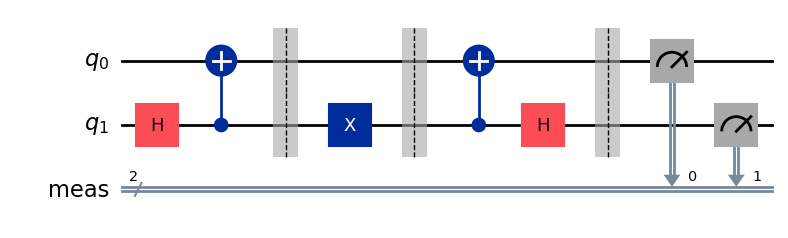

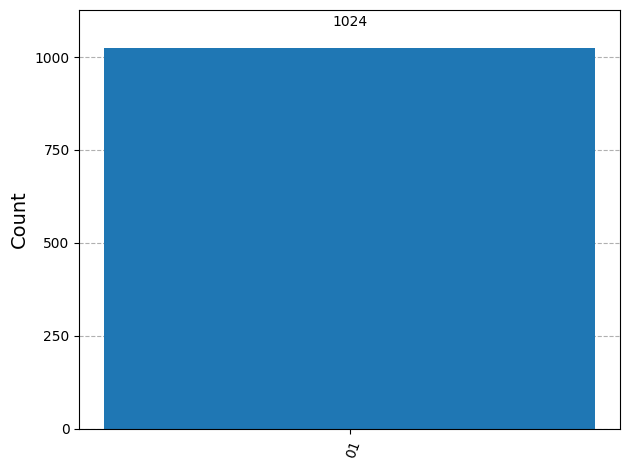

In [30]:
qc=create_bellpair()
qc.barrier()
message="01"
qc=encode_msg(qc,1,message)
qc.barrier()
qc=decode_msg(qc)
qc.measure_all()
display(qc.draw('mpl'))

aer_sim=BasicSimulator()
result=aer_sim.run(qc).result()
counts=result.get_counts(qc)
plot_histogram(counts)

In [ ]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram, plot_bloch_multivector, array_to_latex
from qiskit.result import marginal_counts
from qiskit.quantum_info import random_statevector

In [34]:
qr=QuantumRegister(3,name="qr")
crz=ClassicalRegister(1,name="crz")
crx=ClassicalRegister(1,name="crx")
tc=QuantumCircuit(qr,crz,crx)


In [35]:
def create_bellpair(qc,a,b):
    qc.h(a)
    qc.cx(a,b)


In [41]:
def alice_gates(qc,psi,a):
    qc.cx(psi,a)
    qc.h(psi)

In [38]:
def measure_send(qc,a,b):
    qc.barrier()
    qc.measure(a,0)
    qc.measure(b,1)
    


In [40]:
def bob_gates(qc,qubit,crz,crx):
    qc.x(qubit).c_if(crx,1)
    qc.z(qubit).c_if(crz,1)

In [ ]:
create_bellpair(tc,1,2)
